# 🔧 Notebook 02 - Preprocessamento de Dados

## Tech Challenge 4 - LSTM VALE3

---

### Objetivos deste Notebook:

1. **Normalizar os dados** usando MinMaxScaler
2. **Criar sequências temporais** (janela deslizante)
3. **Dividir em treino/validação/teste** respeitando a ordem temporal
4. **Salvar os dados preparados** para o treinamento

---

### Por que o preprocessamento é tão importante?

O LSTM é uma rede neural, e redes neurais são **sensíveis à escala dos dados**. Se você alimentar preços brutos (ex: R$ 35 a R$ 95), o modelo terá dificuldade em aprender.

Além disso, o LSTM precisa receber os dados em um **formato específico**: sequências de tempo. Não basta passar os preços um a um — precisamos criar "janelas" de dados históricos.

```
Dados Brutos          Preprocessamento           Dados para LSTM
────────────────      ─────────────────          ────────────────
[35, 40, 45, ...]  →  Normalização + Sequências  →  Shape: (samples, 60, 1)
                                                     Valores: 0 a 1
```

## 1. Setup e Carregamento dos Dados

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn para normalização
from sklearn.preprocessing import MinMaxScaler

# Para salvar objetos Python (o scaler)
import joblib

import os
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


In [2]:
# =============================================================================
# CARREGAR DADOS DO NOTEBOOK 01
# =============================================================================

# Carrega os dados limpos que salvamos
df = pd.read_csv('../data/processed/vale3_clean.csv', index_col=0, parse_dates=True)

print("DADOS CARREGADOS")
print("=" * 50)
print(f"Período: {df.index.min().strftime('%d/%m/%Y')} até {df.index.max().strftime('%d/%m/%Y')}")
print(f"Total de registros: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nPrimeiros registros:")
df.head()

DADOS CARREGADOS
Período: 26/01/2021 até 21/01/2026
Total de registros: 1245
Colunas: ['Open', 'High', 'Low', 'Close', 'Volume']

Primeiros registros:


,Open,High,Low,Close,Volume
Date,,,,,
2021-01-26,53.743685,54.419892,52.801626,53.027027,24921600
2021-01-27,52.241017,52.697599,50.975302,51.553253,32419700
2021-01-28,50.975307,52.795855,50.917513,52.651367,35900800
2021-01-29,52.009843,52.506882,50.738352,50.830822,31481600
2021-02-01,52.021399,52.749615,51.194929,52.749615,27135500


In [3]:
# =============================================================================
# CONFIGURAÇÕES DO PREPROCESSAMENTO
# =============================================================================

# Janela temporal: quantos dias passados usamos para prever o próximo
JANELA_TEMPORAL = 60  # ~2 meses de histórico

# Proporções de divisão dos dados variaveis
TRAIN_RATIO = 0.8   # 80% para treino
VAL_RATIO = 0.1     # 10% para validação
TEST_RATIO = 0.1    # 10% para teste

# Coluna que vamos usar para previsão variavel
COLUNA_ALVO = 'Close'

print("CONFIGURAÇÕES")
print("=" * 50)
print(f"Janela temporal: {JANELA_TEMPORAL} dias")
print(f"Divisão: {TRAIN_RATIO*100:.0f}% treino / {VAL_RATIO*100:.0f}% validação / {TEST_RATIO*100:.0f}% teste")
print(f"Coluna alvo: {COLUNA_ALVO}")

CONFIGURAÇÕES
Janela temporal: 60 dias
Divisão: 80% treino / 10% validação / 10% teste
Coluna alvo: Close


## 2. Normalização dos Dados

### Por que normalizar?

Redes neurais funcionam melhor quando os dados estão em uma **escala pequena e uniforme**. Existem várias razões:

1. **Funções de ativação**: Sigmoid e Tanh funcionam na faixa [-1, 1] ou [0, 1]. Valores muito grandes "saturam" essas funções.

2. **Gradientes**: Durante o treinamento, valores muito grandes podem causar "explosão de gradientes" (gradients explodem para infinito).

3. **Convergência**: O otimizador (Adam, SGD) converge mais rápido com dados normalizados.

---

### MinMaxScaler — Como funciona?

O MinMaxScaler transforma os dados para ficarem entre 0 e 1:

```
              x - x_min
x_norm = ─────────────────
           x_max - x_min
```

**Exemplo:**
- Dados originais: [35, 50, 65, 80, 95]
- x_min = 35, x_max = 95
- 35 normalizado: (35-35)/(95-35) = 0.0
- 65 normalizado: (65-35)/(95-35) = 0.5
- 95 normalizado: (95-35)/(95-35) = 1.0
- Dados normalizados: [0.0, 0.25, 0.5, 0.75, 1.0]

---

### ⚠️ IMPORTANTE: Salvar o Scaler!

O scaler guarda os valores de `min` e `max` usados na transformação. Precisamos dele para:

1. **Normalizar novos dados** na API (mesma escala do treino)
2. **Desnormalizar previsões** para obter o preço real em R$

Se não salvarmos, não conseguimos converter as previsões de volta!

In [4]:
# =============================================================================
# EXTRAIR PREÇOS DE FECHAMENTO
# =============================================================================

# Pegamos apenas a coluna Close
precos = df[COLUNA_ALVO].values

print("PREÇOS ORIGINAIS")
print("=" * 50)
print(f"Tipo: {type(precos)}")
print(f"Shape: {precos.shape}")
print(f"Mínimo: R$ {precos.min():.2f}")
print(f"Máximo: R$ {precos.max():.2f}")
print(f"\nPrimeiros 10 valores: {precos[:10].round(2)}")

PREÇOS ORIGINAIS
Tipo: <class 'numpy.ndarray'>
Shape: (1245,)
Mínimo: R$ 42.38
Máximo: R$ 82.50

Primeiros 10 valores: [53.03 51.55 52.65 50.83 52.75 50.66 52.26 51.61 53.57 54.33]


In [5]:
# =============================================================================
# APLICAR NORMALIZAÇÃO
# =============================================================================

# O MinMaxScaler espera dados 2D: (n_samples, n_features)
# Nossos preços são 1D: (n_samples,)
# Precisamos fazer reshape para (n_samples, 1)

precos_2d = precos.reshape(-1, 1)  # -1 significa "calcule automaticamente"

print("Reshape dos dados:")
print(f"  Antes: {precos.shape} (1D)")
print(f"  Depois: {precos_2d.shape} (2D)")

Reshape dos dados:
  Antes: (1245,) (1D)
  Depois: (1245, 1) (2D)


In [6]:
# =============================================================================
# CRIAR E AJUSTAR O SCALER
# =============================================================================

# Cria o scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform faz duas coisas:
# 1. fit: aprende o min e max dos dados
# 2. transform: aplica a transformação
precos_normalizados = scaler.fit_transform(precos_2d)

print("NORMALIZAÇÃO APLICADA")
print("=" * 50)
print(f"\nParâmetros aprendidos pelo scaler:")
print(f"  data_min_: R$ {scaler.data_min_[0]:.2f} (menor preço nos dados)")
print(f"  data_max_: R$ {scaler.data_max_[0]:.2f} (maior preço nos dados)")
print(f"  data_range_: R$ {scaler.data_range_[0]:.2f} (max - min)")

print(f"\nDados normalizados:")
print(f"  Shape: {precos_normalizados.shape}")
print(f"  Mínimo: {precos_normalizados.min():.4f}")
print(f"  Máximo: {precos_normalizados.max():.4f}")
print(f"\nPrimeiros 10 valores normalizados: {precos_normalizados[:10, 0].round(4)}")

NORMALIZAÇÃO APLICADA

Parâmetros aprendidos pelo scaler:
  data_min_: R$ 42.38 (menor preço nos dados)
  data_max_: R$ 82.50 (maior preço nos dados)
  data_range_: R$ 40.12 (max - min)

Dados normalizados:
  Shape: (1245, 1)
  Mínimo: 0.0000
  Máximo: 1.0000

Primeiros 10 valores normalizados: [0.2654 0.2287 0.2561 0.2107 0.2585 0.2065 0.2464 0.23   0.279  0.298 ]


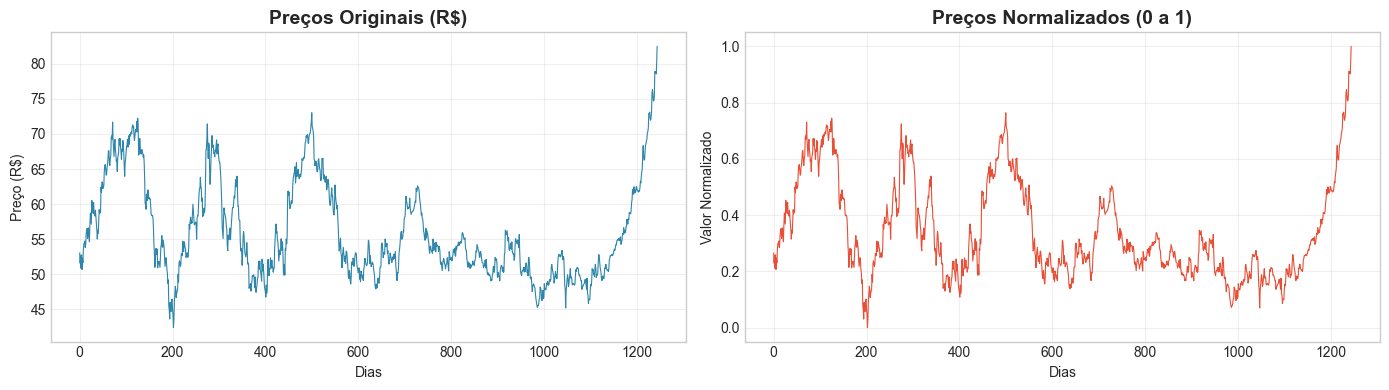

📊 OBSERVAÇÃO:
   Note que o FORMATO da curva é idêntico!
   Apenas a ESCALA mudou: de R$ para valores entre 0 e 1.
   Isso preserva todos os padrões que o LSTM precisa aprender.


In [7]:
# =============================================================================
# VISUALIZAR ANTES E DEPOIS DA NORMALIZAÇÃO
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Antes
axes[0].plot(precos, color='#2E86AB', linewidth=0.8)
axes[0].set_title('Preços Originais (R$)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dias')
axes[0].set_ylabel('Preço (R$)')
axes[0].grid(True, alpha=0.3)

# Depois
axes[1].plot(precos_normalizados, color='#E94F37', linewidth=0.8)
axes[1].set_title('Preços Normalizados (0 a 1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Valor Normalizado')
axes[1].set_ylim(-0.05, 1.05)  # Pequena margem para visualização
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 OBSERVAÇÃO:")
print("   Note que o FORMATO da curva é idêntico!")
print("   Apenas a ESCALA mudou: de R$ para valores entre 0 e 1.")
print("   Isso preserva todos os padrões que o LSTM precisa aprender.")

In [8]:
# =============================================================================
# DEMONSTRAÇÃO: DESNORMALIZAÇÃO
# =============================================================================

# Vamos provar que conseguimos voltar aos valores originais
# Isso é CRUCIAL para a API retornar preços em R$

# Pega os primeiros 5 valores normalizados
amostra_norm = precos_normalizados[:5]

# Desnormaliza (inverse_transform)
amostra_original = scaler.inverse_transform(amostra_norm)

print("DEMONSTRAÇÃO DE DESNORMALIZAÇÃO")
print("=" * 50)
print("\n   Normalizado  →  Desnormalizado  →  Original")
print("   ──────────────────────────────────────────────")
for i in range(5):
    print(f"   {amostra_norm[i, 0]:.4f}       →   R$ {amostra_original[i, 0]:.2f}       →  R$ {precos[i]:.2f}")

print("\n✓ Os valores batem! Podemos converter previsões de volta para R$.")

DEMONSTRAÇÃO DE DESNORMALIZAÇÃO

   Normalizado  →  Desnormalizado  →  Original
   ──────────────────────────────────────────────
   0.2654       →   R$ 53.03       →  R$ 53.03
   0.2287       →   R$ 51.55       →  R$ 51.55
   0.2561       →   R$ 52.65       →  R$ 52.65
   0.2107       →   R$ 50.83       →  R$ 50.83
   0.2585       →   R$ 52.75       →  R$ 52.75

✓ Os valores batem! Podemos converter previsões de volta para R$.


In [9]:
# =============================================================================
# SALVAR O SCALER
# =============================================================================

# Cria pasta se não existir
os.makedirs('../models', exist_ok=True)

# Salva o scaler usando joblib
caminho_scaler = '../models/scaler.joblib'
joblib.dump(scaler, caminho_scaler)

print(f"✓ Scaler salvo em: {caminho_scaler}")
print("\n⚠️  IMPORTANTE: Guarde este arquivo!")
print("   Você precisará dele para:")
print("   1. Normalizar novos dados na API")
print("   2. Converter previsões de volta para R$")

✓ Scaler salvo em: ../models/scaler.joblib

⚠️  IMPORTANTE: Guarde este arquivo!
   Você precisará dele para:
   1. Normalizar novos dados na API
   2. Converter previsões de volta para R$


## 3. Criação de Sequências Temporais

### Por que sequências?

O LSTM é uma rede neural **recorrente** — ela processa dados sequenciais, um passo de cada vez, mantendo uma "memória" do que viu antes.

Para prever o preço de amanhã, precisamos dar ao modelo uma **sequência de dias anteriores**. Isso é chamado de **janela deslizante** (sliding window).

---

### Como funciona a Janela Deslizante?

```
Janela = 5 dias (exemplo simplificado)
Dados: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Sequência 1: X = [10, 11, 12, 13, 14]  →  y = 15
Sequência 2: X = [11, 12, 13, 14, 15]  →  y = 16
Sequência 3: X = [12, 13, 14, 15, 16]  →  y = 17
Sequência 4: X = [13, 14, 15, 16, 17]  →  y = 18
Sequência 5: X = [14, 15, 16, 17, 18]  →  y = 19
```

A janela "desliza" pelos dados, criando pares (entrada, saída).

---

### Por que 60 dias?

- **60 dias ≈ 2-3 meses** de histórico
- Captura tendências de curto/médio prazo
- Não é tão longo que inclua informação "velha" demais
- É um valor comum na literatura de previsão financeira

Você pode experimentar com outros valores (30, 90, 120) e ver o impacto nas métricas.

---

### Formato de saída para o LSTM

O Keras LSTM espera dados no formato:

```
(samples, timesteps, features)
```

- **samples**: número de sequências
- **timesteps**: tamanho da janela (60)
- **features**: número de variáveis (1 = só preço de fechamento)

Exemplo: `(1000, 60, 1)` = 1000 sequências, cada uma com 60 dias, 1 feature.

In [10]:
# =============================================================================
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# =============================================================================

def criar_sequencias(dados, janela):
    """
    Cria sequências de entrada (X) e saída (y) para o LSTM.
    
    Parâmetros:
    -----------
    dados : np.ndarray
        Dados normalizados (shape: n_samples, 1)
    janela : int
        Tamanho da janela temporal
    
    Retorna:
    --------
    X : np.ndarray
        Sequências de entrada (shape: n_sequencias, janela, 1)
    y : np.ndarray
        Valores alvo (shape: n_sequencias,)
    """
    X, y = [], []
    
    # Percorre os dados criando sequências
    for i in range(janela, len(dados)):
        # X: sequência dos últimos 'janela' dias
        X.append(dados[i - janela:i, 0])
        
        # y: valor do próximo dia (o que queremos prever)
        y.append(dados[i, 0])
    
    # Converte para numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    # Reshape X para formato LSTM: (samples, timesteps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    
    return X, y

print("✓ Função criar_sequencias definida!")

✓ Função criar_sequencias definida!


In [11]:
# =============================================================================
# CRIAR AS SEQUÊNCIAS
# =============================================================================

X, y = criar_sequencias(precos_normalizados, JANELA_TEMPORAL)

print("SEQUÊNCIAS CRIADAS")
print("=" * 50)
print(f"\nDados originais: {len(precos_normalizados)} dias")
print(f"Janela temporal: {JANELA_TEMPORAL} dias")
print(f"Sequências geradas: {len(X)}")
print(f"  (perdemos os primeiros {JANELA_TEMPORAL} dias para formar a 1ª sequência)")

print(f"\nShape de X: {X.shape}")
print(f"  - {X.shape[0]} sequências (samples)")
print(f"  - {X.shape[1]} dias por sequência (timesteps)")
print(f"  - {X.shape[2]} feature (preço de fechamento)")

print(f"\nShape de y: {y.shape}")
print(f"  - {y.shape[0]} valores alvo (um para cada sequência)")

SEQUÊNCIAS CRIADAS

Dados originais: 1245 dias
Janela temporal: 60 dias
Sequências geradas: 1185
  (perdemos os primeiros 60 dias para formar a 1ª sequência)

Shape de X: (1185, 60, 1)
  - 1185 sequências (samples)
  - 60 dias por sequência (timesteps)
  - 1 feature (preço de fechamento)

Shape de y: (1185,)
  - 1185 valores alvo (um para cada sequência)


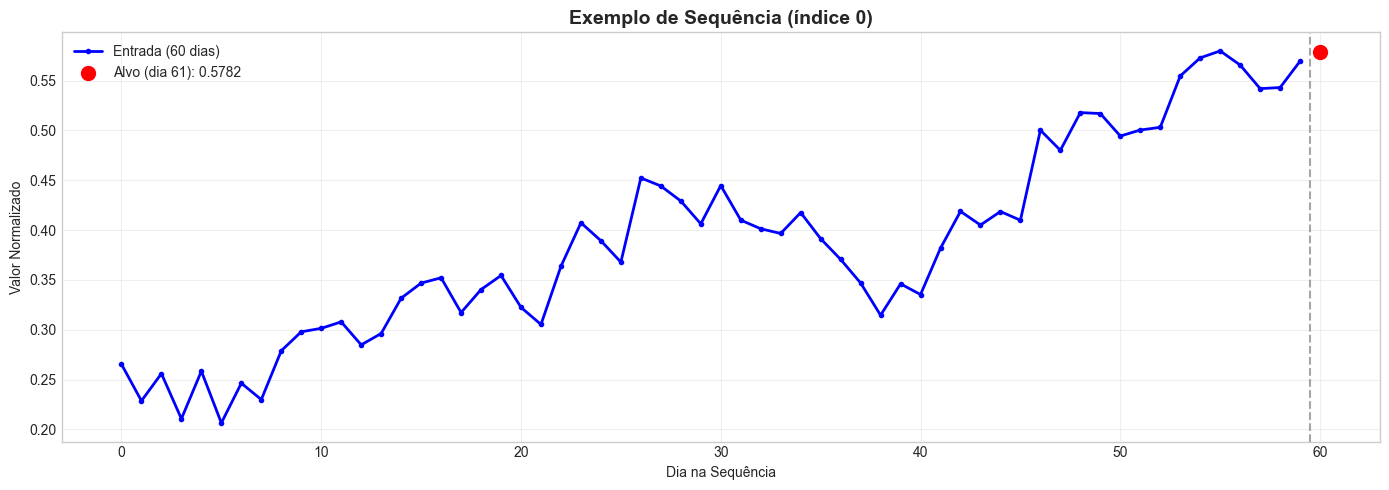

📊 INTERPRETAÇÃO:
   O modelo recebe os 60 pontos azuis como entrada.
   Ele deve aprender a prever o ponto vermelho (próximo dia).


In [12]:
# =============================================================================
# VISUALIZAR UMA SEQUÊNCIA DE EXEMPLO
# =============================================================================

# Pega a primeira sequência como exemplo
exemplo_idx = 0
sequencia_exemplo = X[exemplo_idx, :, 0]  # Shape: (60,)
alvo_exemplo = y[exemplo_idx]

fig, ax = plt.subplots(figsize=(14, 5))

# Plota a sequência de entrada
dias = range(JANELA_TEMPORAL)
ax.plot(dias, sequencia_exemplo, 'b-', linewidth=2, label='Entrada (60 dias)', marker='o', markersize=3)

# Plota o valor alvo
ax.scatter([JANELA_TEMPORAL], [alvo_exemplo], color='red', s=100, zorder=5, label=f'Alvo (dia 61): {alvo_exemplo:.4f}')

# Linha vertical separando entrada do alvo
ax.axvline(x=JANELA_TEMPORAL-0.5, color='gray', linestyle='--', alpha=0.7)

ax.set_title(f'Exemplo de Sequência (índice {exemplo_idx})', fontsize=14, fontweight='bold')
ax.set_xlabel('Dia na Sequência')
ax.set_ylabel('Valor Normalizado')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 INTERPRETAÇÃO:")
print(f"   O modelo recebe os {JANELA_TEMPORAL} pontos azuis como entrada.")
print(f"   Ele deve aprender a prever o ponto vermelho (próximo dia).")

## 4. Divisão em Treino, Validação e Teste

### Por que dividir os dados?

- **Treino (80%)**: Dados que o modelo usa para aprender
- **Validação (10%)**: Dados para ajustar hiperparâmetros e evitar overfitting
- **Teste (10%)**: Dados "sagrados" — só tocamos no final para avaliação

---

### ⚠️ REGRA DE OURO: Não embaralhar séries temporais!

Em problemas de classificação comum, é normal embaralhar os dados antes de dividir. **Em séries temporais, isso é PROIBIDO!**

**Por quê?**

Se embaralharmos, o modelo pode ver dados do futuro durante o treino (data leakage). Isso faz o modelo parecer bom nos testes, mas falhar miseravelmente na vida real.

```
❌ ERRADO (embaralhado):
Treino: [jan, mar, dez, jun, set, ...]  ← Vê dezembro antes de junho!
Teste:  [fev, jul, out, ...]

✅ CERTO (sequencial):
Treino: [jan, fev, mar, abr, mai, jun, jul, ago]  ← Passado
Valid:  [set, out]                                 ← Presente
Teste:  [nov, dez]                                 ← Futuro
```

O modelo só pode usar informações do **passado** para prever o **futuro**.

In [13]:
# =============================================================================
# CALCULAR ÍNDICES DE DIVISÃO
# =============================================================================

n_total = len(X)

# Calcula os pontos de corte
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)
n_test = n_total - n_train - n_val  # O que sobrar vai para teste

print("DIVISÃO DOS DADOS")
print("=" * 50)
print(f"\nTotal de sequências: {n_total}")
print(f"\nDivisão planejada:")
print(f"  Treino:    {n_train} sequências ({n_train/n_total*100:.1f}%)")
print(f"  Validação: {n_val} sequências ({n_val/n_total*100:.1f}%)")
print(f"  Teste:     {n_test} sequências ({n_test/n_total*100:.1f}%)")

DIVISÃO DOS DADOS

Total de sequências: 1185

Divisão planejada:
  Treino:    948 sequências (80.0%)
  Validação: 118 sequências (10.0%)
  Teste:     119 sequências (10.0%)


In [14]:
# =============================================================================
# REALIZAR A DIVISÃO (SEM EMBARALHAR!)
# =============================================================================

# Divisão sequencial - respeitando a ordem temporal
X_train = X[:n_train]
y_train = y[:n_train]

X_val = X[n_train:n_train + n_val]
y_val = y[n_train:n_train + n_val]

X_test = X[n_train + n_val:]
y_test = y[n_train + n_val:]

print("DIVISÃO REALIZADA")
print("=" * 50)
print(f"\nConjunto de Treino:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

print(f"\nConjunto de Validação:")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")

print(f"\nConjunto de Teste:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

DIVISÃO REALIZADA

Conjunto de Treino:
  X_train: (948, 60, 1)
  y_train: (948,)

Conjunto de Validação:
  X_val: (118, 60, 1)
  y_val: (118,)

Conjunto de Teste:
  X_test: (119, 60, 1)
  y_test: (119,)


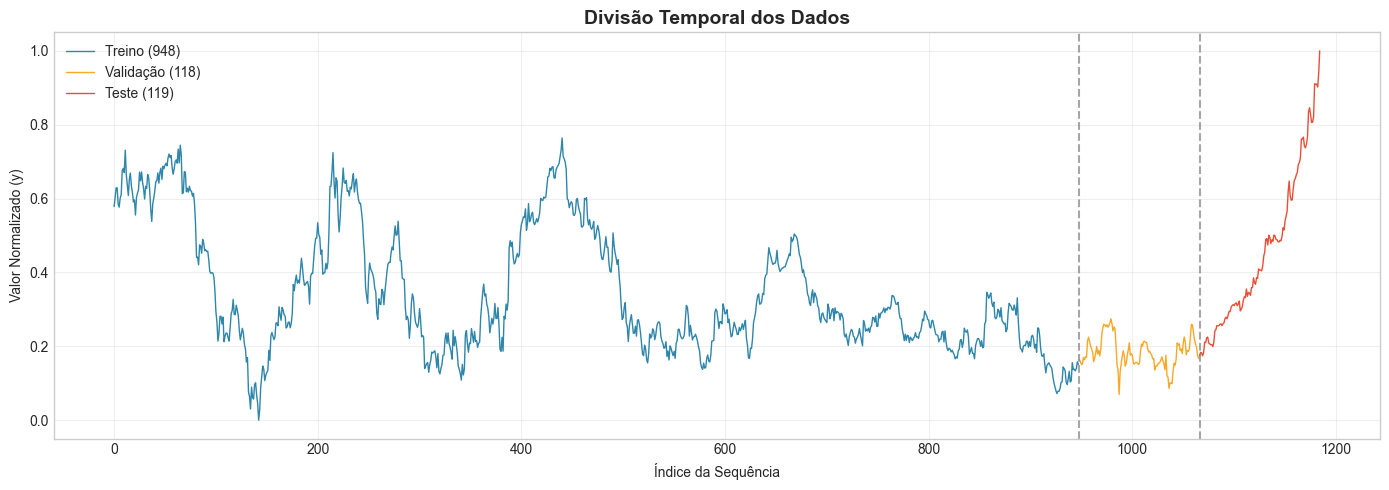

📊 OBSERVAÇÃO:
   A divisão é SEQUENCIAL no tempo.
   Treino = passado mais distante
   Validação = passado recente
   Teste = período mais recente (simula 'futuro')


In [15]:
# =============================================================================
# VISUALIZAR A DIVISÃO TEMPORAL
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Índices para cada conjunto
idx_train = range(n_train)
idx_val = range(n_train, n_train + n_val)
idx_test = range(n_train + n_val, n_total)

# Plota cada conjunto com cor diferente
ax.plot(idx_train, y_train, color='#2E86AB', linewidth=1, label=f'Treino ({n_train})')
ax.plot(idx_val, y_val, color='#F9A826', linewidth=1, label=f'Validação ({n_val})')
ax.plot(idx_test, y_test, color='#E94F37', linewidth=1, label=f'Teste ({n_test})')

# Linhas verticais nos pontos de corte
ax.axvline(x=n_train, color='gray', linestyle='--', alpha=0.7)
ax.axvline(x=n_train + n_val, color='gray', linestyle='--', alpha=0.7)

ax.set_title('Divisão Temporal dos Dados', fontsize=14, fontweight='bold')
ax.set_xlabel('Índice da Sequência')
ax.set_ylabel('Valor Normalizado (y)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 OBSERVAÇÃO:")
print("   A divisão é SEQUENCIAL no tempo.")
print("   Treino = passado mais distante")
print("   Validação = passado recente")
print("   Teste = período mais recente (simula 'futuro')")

In [16]:
# =============================================================================
# VERIFICAR DATAS CORRESPONDENTES
# =============================================================================

# O índice i em X/y corresponde ao dia (i + JANELA_TEMPORAL) no DataFrame original
# porque perdemos os primeiros JANELA_TEMPORAL dias para criar a primeira sequência

def idx_para_data(idx, df, janela):
    """Converte índice da sequência para data correspondente."""
    return df.index[idx + janela]

print("PERÍODOS CORRESPONDENTES")
print("=" * 50)

print(f"\nTreino:")
print(f"  De: {idx_para_data(0, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")
print(f"  Até: {idx_para_data(n_train-1, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")

print(f"\nValidação:")
print(f"  De: {idx_para_data(n_train, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")
print(f"  Até: {idx_para_data(n_train + n_val - 1, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")

print(f"\nTeste:")
print(f"  De: {idx_para_data(n_train + n_val, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")
print(f"  Até: {idx_para_data(n_total - 1, df, JANELA_TEMPORAL).strftime('%d/%m/%Y')}")

PERÍODOS CORRESPONDENTES

Treino:
  De: 26/04/2021
  Até: 07/02/2025

Validação:
  De: 10/02/2025
  Até: 31/07/2025

Teste:
  De: 01/08/2025
  Até: 21/01/2026


## 5. Salvar Dados Preparados

Vamos salvar tudo para usar no próximo notebook (treinamento do modelo).

In [17]:
# =============================================================================
# SALVAR DADOS PROCESSADOS
# =============================================================================

# Cria pasta se não existir
os.makedirs('../data/processed', exist_ok=True)

# Salva os arrays numpy
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/y_test.npy', y_test)

print("ARQUIVOS SALVOS")
print("=" * 50)
print("\n../data/processed/")
print("  ├── X_train.npy")
print("  ├── X_val.npy")
print("  ├── X_test.npy")
print("  ├── y_train.npy")
print("  ├── y_val.npy")
print("  └── y_test.npy")
print("\n../models/")
print("  └── scaler.joblib")

ARQUIVOS SALVOS

../data/processed/
  ├── X_train.npy
  ├── X_val.npy
  ├── X_test.npy
  ├── y_train.npy
  ├── y_val.npy
  └── y_test.npy

../models/
  └── scaler.joblib


In [18]:
# =============================================================================
# SALVAR METADADOS DA CONFIGURAÇÃO
# =============================================================================

import json

config = {
    'janela_temporal': JANELA_TEMPORAL,
    'coluna_alvo': COLUNA_ALVO,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'n_train': n_train,
    'n_val': n_val,
    'n_test': n_test,
    'input_shape': list(X_train.shape[1:]),  # (60, 1)
    'scaler_min': float(scaler.data_min_[0]),
    'scaler_max': float(scaler.data_max_[0])
}

with open('../data/processed/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Configuração salva em: ../data/processed/config.json")
print("\nConteúdo:")
print(json.dumps(config, indent=2))

✓ Configuração salva em: ../data/processed/config.json

Conteúdo:
{
  "janela_temporal": 60,
  "coluna_alvo": "Close",
  "train_ratio": 0.8,
  "val_ratio": 0.1,
  "test_ratio": 0.1,
  "n_train": 948,
  "n_val": 118,
  "n_test": 119,
  "input_shape": [
    60,
    1
  ],
  "scaler_min": 42.37786483764648,
  "scaler_max": 82.5
}


## 6. Resumo e Próximos Passos

In [19]:
# =============================================================================
# RESUMO FINAL
# =============================================================================

print("=" * 60)
print("RESUMO DO PREPROCESSAMENTO")
print("=" * 60)

print(f"\n📊 NORMALIZAÇÃO:")
print(f"   Método: MinMaxScaler (0 a 1)")
print(f"   Preço mínimo original: R$ {scaler.data_min_[0]:.2f}")
print(f"   Preço máximo original: R$ {scaler.data_max_[0]:.2f}")

print(f"\n🔢 SEQUÊNCIAS:")
print(f"   Janela temporal: {JANELA_TEMPORAL} dias")
print(f"   Total de sequências: {n_total}")
print(f"   Shape de entrada: {X_train.shape[1:]} (timesteps, features)")

print(f"\n📁 DIVISÃO DOS DADOS:")
print(f"   Treino:    {n_train} sequências ({n_train/n_total*100:.1f}%)")
print(f"   Validação: {n_val} sequências ({n_val/n_total*100:.1f}%)")
print(f"   Teste:     {n_test} sequências ({n_test/n_total*100:.1f}%)")

print(f"\n✅ ARQUIVOS GERADOS:")
print(f"   ../data/processed/X_train.npy, y_train.npy")
print(f"   ../data/processed/X_val.npy, y_val.npy")
print(f"   ../data/processed/X_test.npy, y_test.npy")
print(f"   ../data/processed/config.json")
print(f"   ../models/scaler.joblib")

print("\n" + "=" * 60)
print("PRÓXIMO PASSO: Notebook 03 - Modelo LSTM")
print("=" * 60)
print("\nNo próximo notebook vamos:")
print("  1. Construir a arquitetura do LSTM")
print("  2. Treinar o modelo com early stopping")
print("  3. Avaliar com métricas (MAE, RMSE, MAPE)")
print("  4. Visualizar previsões vs valores reais")
print("  5. Salvar o modelo treinado")

RESUMO DO PREPROCESSAMENTO

📊 NORMALIZAÇÃO:
   Método: MinMaxScaler (0 a 1)
   Preço mínimo original: R$ 42.38
   Preço máximo original: R$ 82.50

🔢 SEQUÊNCIAS:
   Janela temporal: 60 dias
   Total de sequências: 1185
   Shape de entrada: (60, 1) (timesteps, features)

📁 DIVISÃO DOS DADOS:
   Treino:    948 sequências (80.0%)
   Validação: 118 sequências (10.0%)
   Teste:     119 sequências (10.0%)

✅ ARQUIVOS GERADOS:
   ../data/processed/X_train.npy, y_train.npy
   ../data/processed/X_val.npy, y_val.npy
   ../data/processed/X_test.npy, y_test.npy
   ../data/processed/config.json
   ../models/scaler.joblib

PRÓXIMO PASSO: Notebook 03 - Modelo LSTM

No próximo notebook vamos:
  1. Construir a arquitetura do LSTM
  2. Treinar o modelo com early stopping
  3. Avaliar com métricas (MAE, RMSE, MAPE)
  4. Visualizar previsões vs valores reais
  5. Salvar o modelo treinado
